# **TP Wavelets**

In this TP, we will work on some fundamental concepts in Wavelets and compression of images.

First we'll briefly check the limitations of the Fourier transform. We'll then check some fundamental properties of a family of Wavelets and compute the Wavelet transform of a very simple signal. In the second part of the TP, we will use the DWT to compress and image.

Make sure to sequentially run all the cells in each section, so that the intermediate variables / packages will carry over to the next cell.

We recommend you save a copy of this colab in your drive so you don't lose progress!

**Note:** Several points have associated questions. When answering these questions, all responses should be properly justified.

# Setup
First, we install PyWavelets

In [32]:
!pip install PyWavelets

In [33]:
import pywt

pywt.__version__

'1.8.0'

# Important
Google Colab is an interesting tool to try things out quickly. However, Google Colab and more general Notebooks are not meant to be an Integrated Development Environment (IDE). For a real job, please use an actual IDE like PyCharm or VS Code.

# Limitation of the Fourier Transform
*   Create a sinusoidal signal of 2.5 seconds of duration.
*   Set up a sampling rate of 20kHz. The signal should be divided in 5 parts of 0.5 seconds of duration each.
*  The signal should have the following frequencies in this order {10 Hz, 30 Hz, 60 Hz, 30 Hz, 10 Hz}.

In [34]:
# Your code here
import numpy as np

# parameters initialization
sr = 20000
d_seg = 0.5
frequence = [10, 30,60, 30, 10]

# number of samples for each segment
N_samples = int(sr * d_seg)
# create time base for each segment
t_base = np.arange(N_samples) / sr

# create signal containing segments of different frequencies
signal = np.array([])

for f in frequence:
    signal = np.append(signal, np.sin(2 * np.pi * f * t_base))

# create total time base for the x plot
time = np.arange(len(signal)) / sr


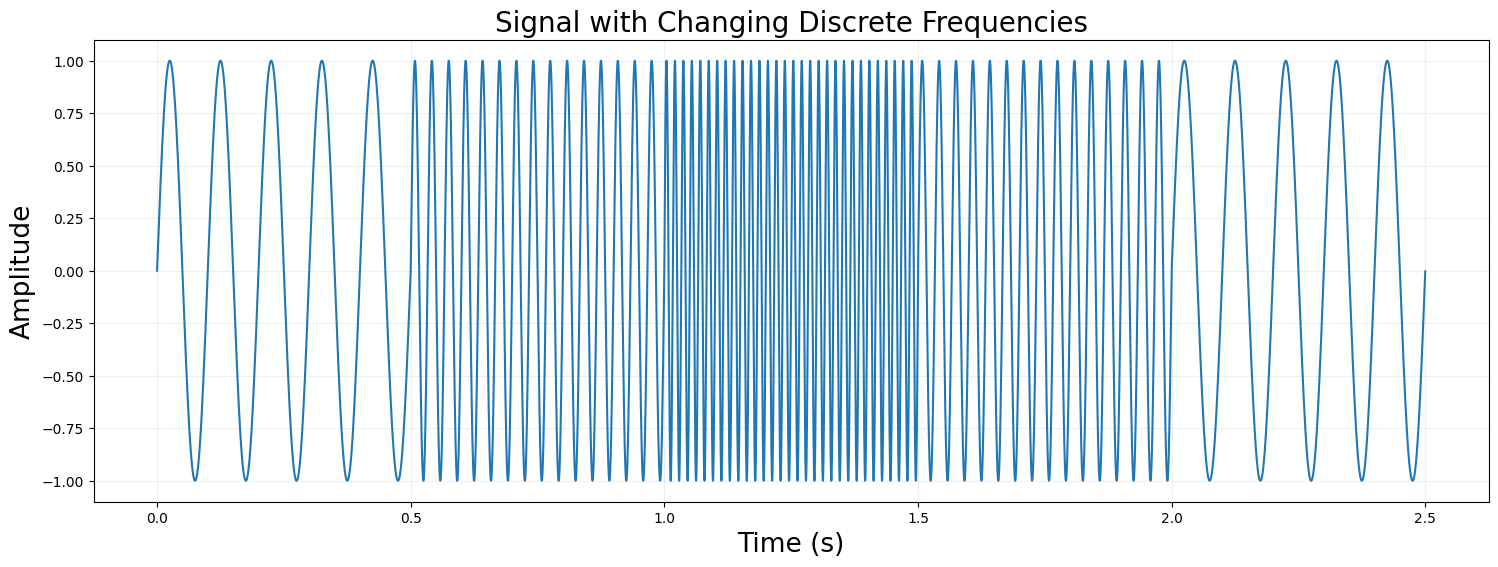

In [35]:
import matplotlib
import matplotlib.pyplot as plt

font_size = 20

plt.figure(figsize=(18, 6))

plt.plot(time, signal, linewidth=1.5)
plt.title('Signal with Changing Discrete Frequencies', fontsize=font_size)
plt.xlabel('Time (s)', fontsize=font_size-1)
plt.ylabel('Amplitude', fontsize=font_size-1)
plt.grid(alpha=0.2)

Now, you should compute the Discrete Fourier Transform of the signal. You can use any library from Python you prefer. You might need to cut the x-axis in the Fourier transform up to 100 Hz in the visualization. Please check https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html and https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html

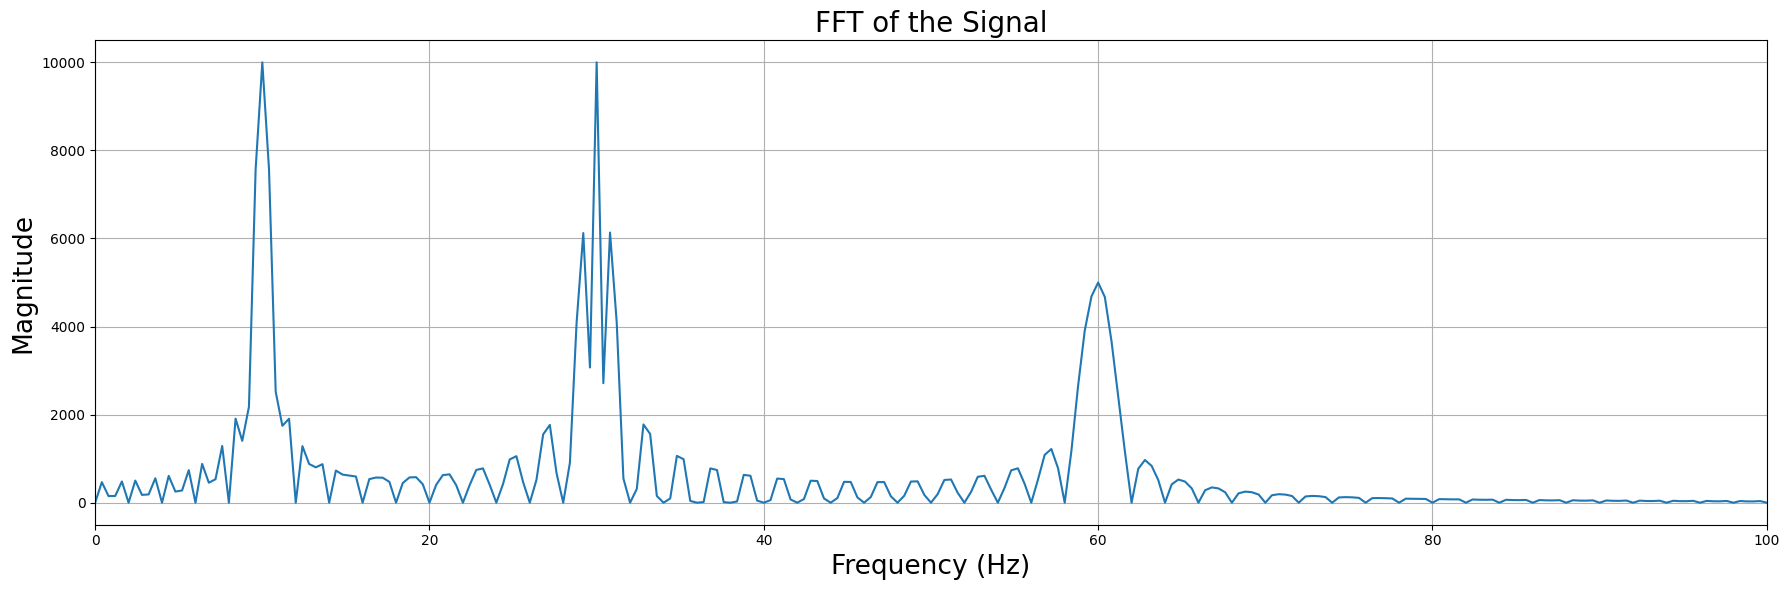

In [36]:
# Your code here
# Perform FFT of the signal
fft = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(signal), 1/sr)

#we want to keep only the positive frequencies for visualization, so we create a mask for that
mask = fft_freq >= 0
frequency_positive = fft_freq[mask]
fft_positive = fft[mask]

# graph the FFT of the signal
plt.figure(figsize=(18, 6))
plt.plot(frequency_positive, np.abs(fft_positive), linewidth=1.5)
#Impose a limit on the x-axis to focus on the relevant frequency range
plt.xlim(0, 100)
plt.title('FFT of the Signal', fontsize=font_size)
plt.xlabel('Frequency (Hz)', fontsize=font_size-1)
plt.ylabel('Magnitude', fontsize=font_size-1)
plt.grid(True)
plt.tight_layout()
plt.show()

**QUESTIONS**

1) Does the established sampling rate satisfy the Nyquist-Shannon sampling theorem to avoid aliasing? Please justify.

2) What can you say from the signal looking **only** at the Fourier transform?

3) Can you be certain about the location of some frequency component in the time domain? Why?

**YOUR ANSWERS HERE:**

1)

2)

3)

# **Mother Wavelet**
As we saw in the course, a wavelet is not just a function but a whole family of functions that satisfy certain requirements. In this part of the TP we're gonna work with the Morlet wavelet defined as follows: $\Psi(t)=k e^{iw_0t}e^{-\frac{1}{2}(\frac{t}{\sigma})^2}$. Please generate a Morlet wavelet in Python **WITHOUT using PyWavelets** with the following parameters:

-Center frequency of the wavelet = 10 Hz

-Sampling rate $\eta$ = 20000 Hz

-$k=\frac{1}{\sqrt{\eta}}$

-$\sigma = 0.1$

You can generate the wavelet between -1 and 1 seconds, so the time duration of the wavelet is 2 seconds. For this part, you just need to generate the real part of the wavelet.

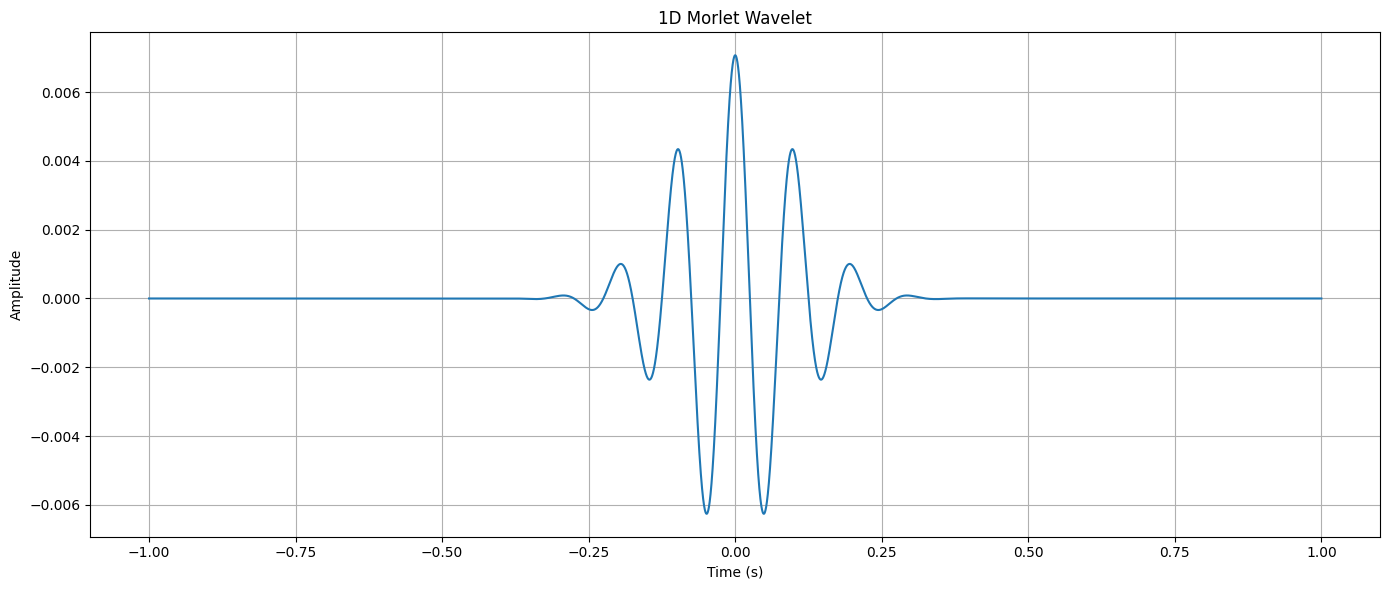

In [37]:
# Your code here
f0 = 10
w0 = 2 * np.pi * f0 #aungular frequency
sample_rate = 20000
k = 1/np.sqrt(sample_rate)
sigma = 0.1

start_time = -1
end_time = 1

# create time vector for the Morlet wavelet
t= np.arange(start_time, end_time, 1/sample_rate)

# create the Morlet wavelet real part using the formula
real_psi = k* np.cos( w0 * t) * np.exp(-0.5 * (t/sigma)**2)

# Plot the real part of the Morlet wavelet in 1D
plt.figure(figsize=(14, 6))

plt.plot(t, real_psi, linewidth=1.5)
plt.title('1D Morlet Wavelet')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

Please show that the mother wavelet we just created satisfies the admissibility and the finite energy conditions:

In [38]:
# Your code here
# admissibility condition for the Morlet wavelet: mean of the wavelet should be zero
dt = 1/sample_rate

admissibility = np.trapezoid(real_psi, dx=dt)
print(f"Admissibility condition (should be close to 0): {admissibility}")

# show that the signal has finite energy by calculating the energy of the signal
energy = np.trapezoid(real_psi**2, dx=dt)
print(f"Energy of the Morlet wavelet: {energy}")

Admissibility condition (should be close to 0): 4.741824476187762e-12
Energy of the Morlet wavelet: 4.431134627264279e-06


**Note:** In real life, you have to deal with finite-precision related problems. Therefore, if for the admissibility condition you don't have exactly the value you were expecting for, don't worry.

# **Convolution**

As we saw in the course, we need a measure of similarity to compute the wavelet transform. We also saw that we can easily compute the shift in time and similarity calculation with the 1-D convolutions.

* Generate a chirp sinusoidal signal from -5 to 5 seconds with an initial frequency of 5 Hz and final frequency of 15 Hz and sampling rate of 20kHz:

Text(0.5, 0, 'Time')

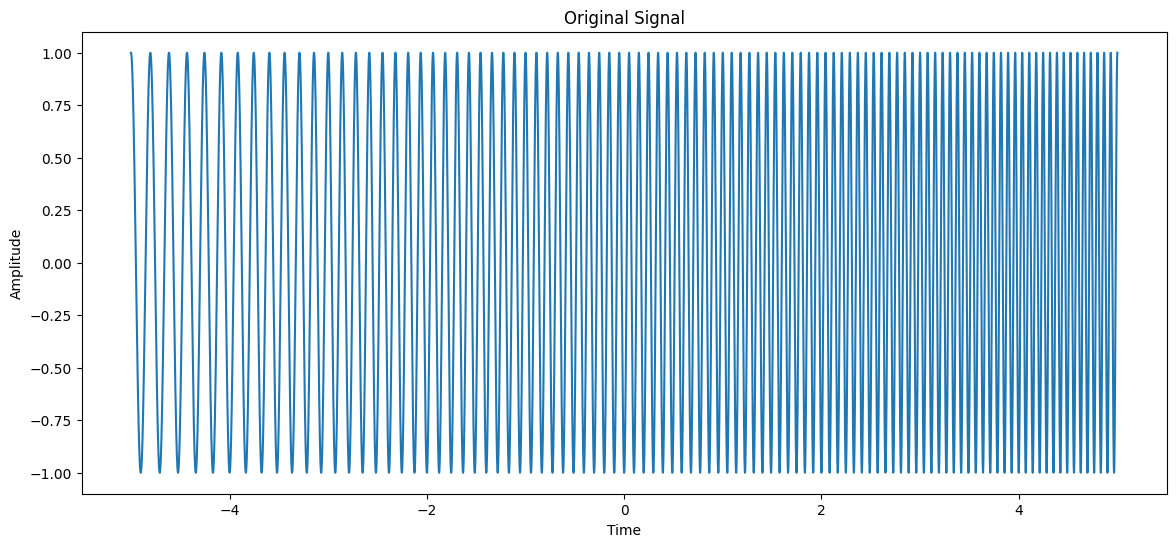

In [39]:
# Your code here
from scipy.signal import chirp

# initialize parameters for the chirp signal
start_time = -5
end_time = 5
f0 = 5
f_end = 15
sample_rate = 20000

# create time vector for the chirp signal
time_signal = np.arange(start_time, end_time, 1/sample_rate)

# shift the time vector to start from 0 for the chirp function
# The chirp function expects the time vector to start from 0, so we need to shift it accordingly
time_shifted = time_signal - start_time
chirp_signal = chirp(time_shifted, f0=f0, f1=f_end, t1=end_time-start_time, method='linear')

#plot the chirp signal
plt.figure(figsize=(14, 6))
plt.plot(time_signal, chirp_signal)
plt.title('Original Signal')
plt.ylabel('Amplitude')
plt.xlabel('Time')

Now create a Morlet wavelet with the following parameters:

* Center frequency of the wavelet = 10 Hz

* Sampling rate $\eta$ = 20000 Hz

* $k=\frac{1}{\sqrt{\eta}}$
* $\sigma = 0.2$
* Duration = 2 seconds


Text(0.5, 0, 'Time')

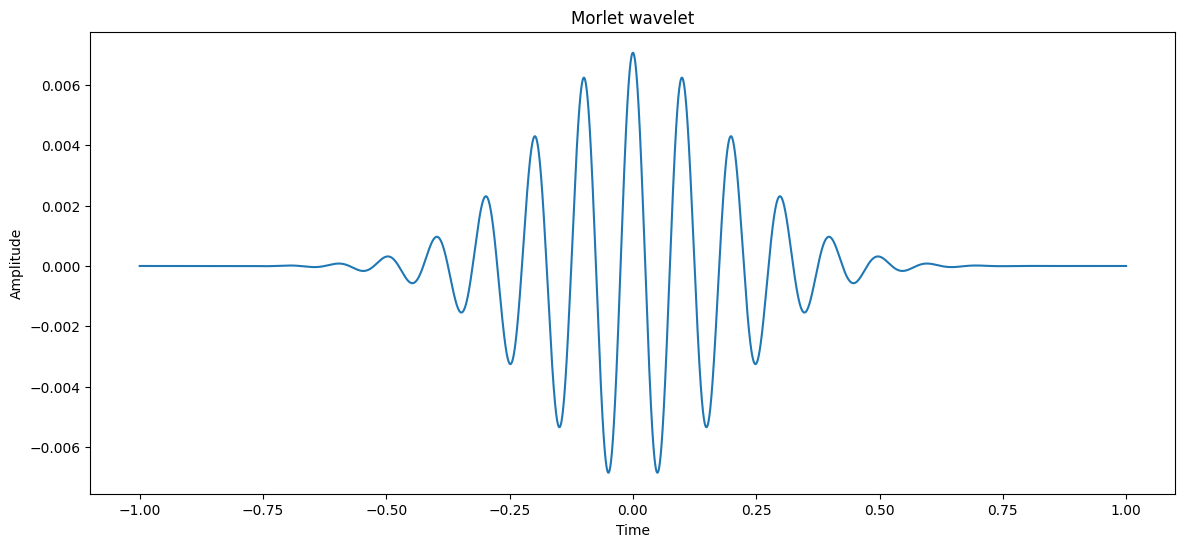

In [40]:
# Your code here
# initialize parameters for the Morlet wavelet
f0 = 10
w0 = 2 * np.pi * f0 #angular frequency
sample_rate = 20000
k = 1/np.sqrt(sample_rate)
sigma = 0.2
duration = 2

time = np.arange(-duration/2, duration/2, 1/sample_rate)
morlet_wavelet = k * np.exp(1j * w0 * time) * np.exp(-0.5 * (time/sigma)**2)

plt.figure(figsize=(14, 6))
plt.plot(time, np.real(morlet_wavelet))

plt.title('Morlet wavelet')
plt.ylabel('Amplitude')
plt.xlabel('Time')

Compute the convolution between the signal and $Re(\Psi(t))$. For reference on how to perform convolution with scipy 'convolve' function, please check https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

Text(0, 0.5, 'Amplitude')

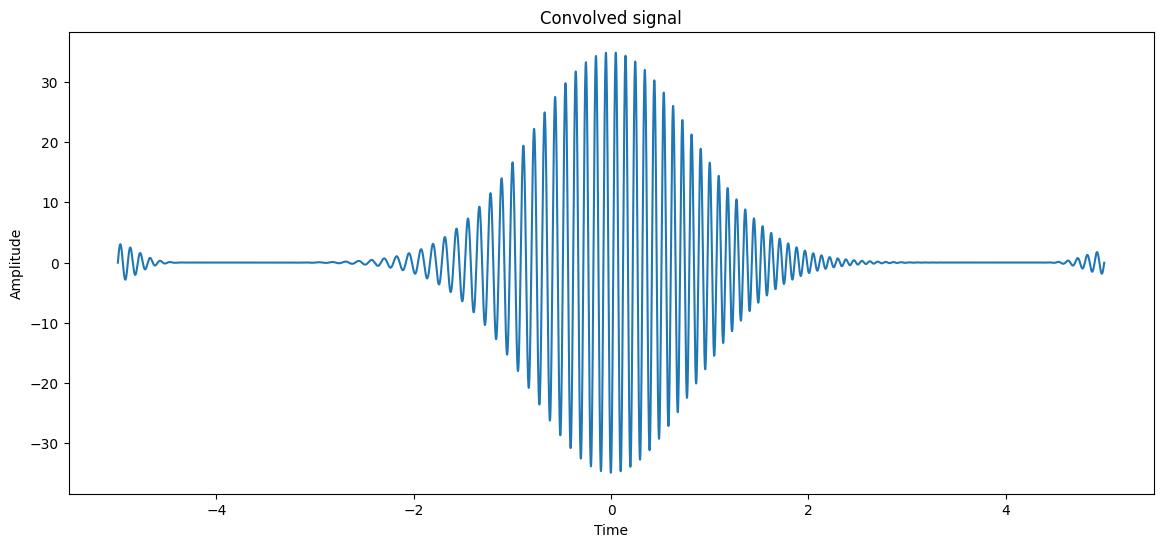

In [41]:
# Your code here
from scipy.signal import convolve
# We convolve the chirp signal with the real part of the Morlet wavelet to analyze the time-frequency characteristics of the signal. 
# The 'same' mode ensures that the output signal has the same length as the input signal.
convolved_signal = convolve(chirp_signal, np.real(morlet_wavelet), mode='same')

plt.figure(figsize=(14, 6))
plt.plot(time_signal, convolved_signal)
plt.title('Convolved signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')

There are some points where the convolution is zero, even in regions of high similarity between the wavelet and the signal. **Is this OK?** If it's not, propose a solution to that.

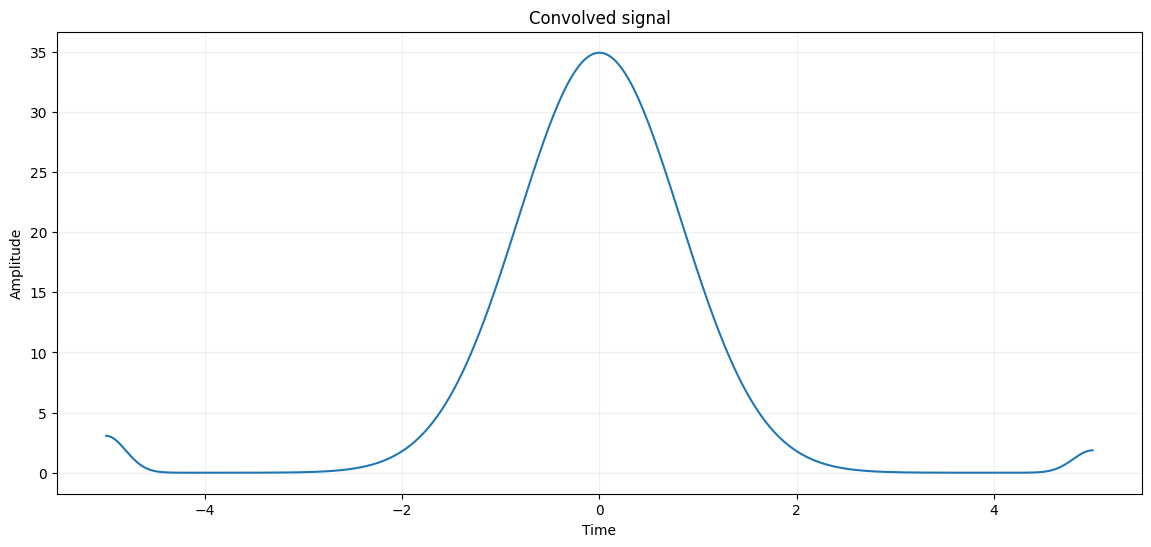

In [42]:
# Your code here

#convolution of the chirp signal with the Morlet wavelet, also the imaginary part os necessary for the complete analysis of the signal in the time-frequency domain.
convolved_signal = convolve(chirp_signal, morlet_wavelet, mode='same')

# we take the absolute value of the convolved signal to visualize the magnitude of the result, which is often more informative in time-frequency analysis.
convolved_signal_magnitude = np.abs(convolved_signal)


plt.figure(figsize=(14, 6))
plt.plot(time_signal, convolved_signal_magnitude)
plt.title('Convolved signal')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(alpha=0.2)

# **Haar DWT by hand**

Before using Python libraries, we first compute a very small Haar wavelet transform by hand.

Consider the discrete signal

$
x = [8,\;4,\;6,\;2,\;5,\;5,\;1,\;3].
$

For a one-level Haar transform, we group the samples by pairs:

$
(x_0,x_1),\quad (x_2,x_3),\quad (x_4,x_5),\quad (x_6,x_7).
$

For each pair, the approximation and detail coefficients are defined as

$
a_k = \frac{x_{2k}+x_{2k+1}}{\sqrt{2}},
$

$
d_k = \frac{x_{2k}-x_{2k+1}}{\sqrt{2}}.
$

---

## Questions

1. Compute the one-level Haar transform by hand

Compute

$
a = [a_0,a_1,a_2,a_3]
$

and

$
d = [d_0,d_1,d_2,d_3].
$

---

2. Reconstruct the original signal

The inverse Haar transform is

$
x_{2k} = \frac{a_k+d_k}{\sqrt{2}},
$

$
x_{2k+1} = \frac{a_k-d_k}{\sqrt{2}}.
$

Use your coefficients \(a\) and \(d\) to reconstruct \(x\).

Do you recover the original signal exactly?

---

3. Lossy reconstruction

Now set the two smallest coefficients, in absolute value, to zero.

Reconstruct the signal again.

Which samples changed?  
What information was lost?

---

Please sign this exercise with your name, and give it to your instructor before leaving.

# **Image Compression**
For this part, we'll use the Discrete Wavelet Transform (DWT) implemented as a filter bank to do image compression. The first step is to have an image to compress. For doing so you can use the following piece of code to download an image of Trudy.

In [43]:
!wget https://perso.telecom-paristech.fr/jgiraldo/courses/wavelets/Trudy_for_compression.jpeg

--2026-06-19 17:43:55--  https://perso.telecom-paristech.fr/jgiraldo/courses/wavelets/Trudy_for_compression.jpeg
Resolving perso.telecom-paristech.fr (perso.telecom-paristech.fr)... 2a04:8ec0:0:a::89c2:16e3, 137.194.22.227
Connecting to perso.telecom-paristech.fr (perso.telecom-paristech.fr)|2a04:8ec0:0:a::89c2:16e3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 557430 (544K) [image/jpeg]
Saving to: ‘Trudy_for_compression.jpeg.1’

Trudy_for_compressi 100%[===================>] 544.37K  --.-KB/s    in 0.04s   

2026-06-19 17:43:55 (15.2 MB/s) - ‘Trudy_for_compression.jpeg.1’ saved [557430/557430]



**Visualize image:** With the following code you can visualize the image. If you're using Google Collab, most probably you already have the open cv library installed. If you're using Jupyter Notebook for example, you'll have to install open cv if it's not already installed.

In [44]:
# Let us define a function for visualizing images
def show_image(image, title='Input Image', font_size=12,fig_size = (10, 10)):
  #A function that uses matplotlib to show grayscale images
  plt.figure(figsize=fig_size)
  plt.imshow(image, cmap='gray')
  plt.title(title, fontsize=font_size)
  plt.axis('off')

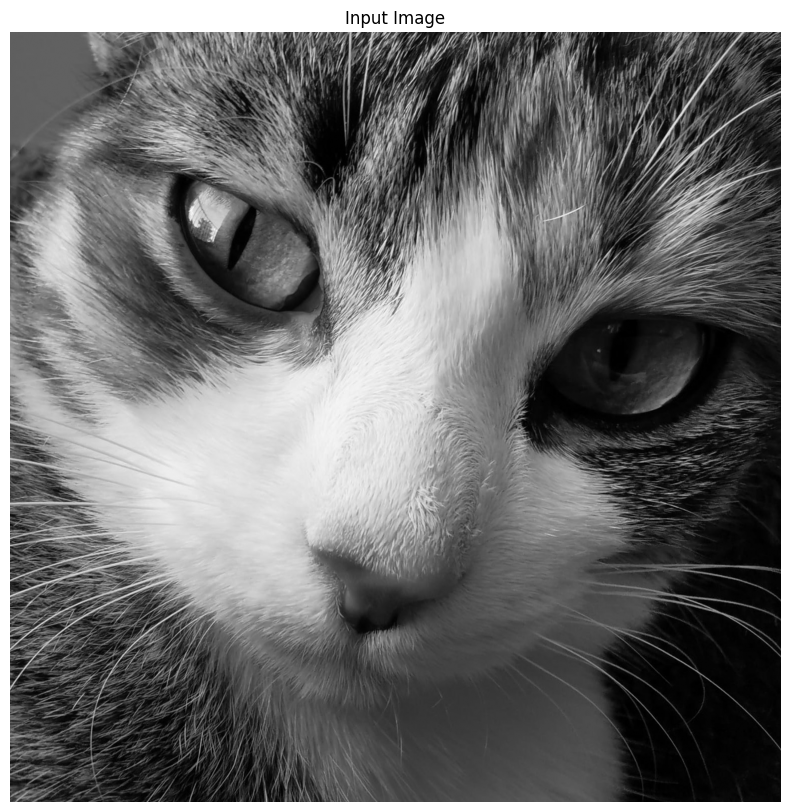

In [45]:
import cv2

# Load your image as a grayscale
input_image = cv2.imread('Trudy_for_compression.jpeg', cv2.IMREAD_GRAYSCALE)
# Display the original image
show_image(input_image, 'Input Image')

If you use some wavelet function (Biorthogonal 1.3 in this case), the 1-level 2D wavelet decomposition of our input image is given as follows:

In [46]:
# # You can see a list of wavelet families
import pywt
pywt.families()

['haar',
 'db',
 'sym',
 'coif',
 'bior',
 'rbio',
 'dmey',
 'gaus',
 'mexh',
 'morl',
 'cgau',
 'shan',
 'fbsp',
 'cmor']

In [47]:
# For each family, you can list the available wavelets
pywt.wavelist(family='bior', kind='all')

['bior1.1',
 'bior1.3',
 'bior1.5',
 'bior2.2',
 'bior2.4',
 'bior2.6',
 'bior2.8',
 'bior3.1',
 'bior3.3',
 'bior3.5',
 'bior3.7',
 'bior3.9',
 'bior4.4',
 'bior5.5',
 'bior6.8']

In the previous image we applied a threshold in the wavelet coefficients for visualization purposes. **Please explain the meaning of each of these 4 images**.

**YOUR ANSWER HERE:**



Now, you should compute the six-levels 2D wavelet decomposition of the input image with a Daubechies wavelet with six vanishing moments using the PyWavelet library. Please check https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html#d-multilevel-decomposition-using-wavedec2

In [48]:
# Your code here
#six levels of decomposition of Daubechies wavelet
coeffs = pywt.wavedec2(input_image, wavelet='db4', level=6)


* Set a threshold of value of 100 and take to zero the values less than that in the 2D wavelet decomposition. **Note:** You should only threshold the outputs of the high-pass filters.



In [49]:
# Your code here
# threshold of high-pass filters 
threshold = 100
# Keep approximation coefficients unchanged
cA = coeffs[0]

# Threshold only detail coefficients
new_coeffs = [cA]

for (cH, cV, cD) in coeffs[1:]:

    cH_thr = pywt.threshold(cH, threshold, mode="hard")
    cV_thr = pywt.threshold(cV, threshold, mode="hard")
    cD_thr = pywt.threshold(cD, threshold, mode="hard")

    new_coeffs.append((cH_thr, cV_thr, cD_thr))


* Compute the IDWT to reconstruct the image after the "compression". Check https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html#d-multilevel-reconstruction-using-waverec2 as a reference.

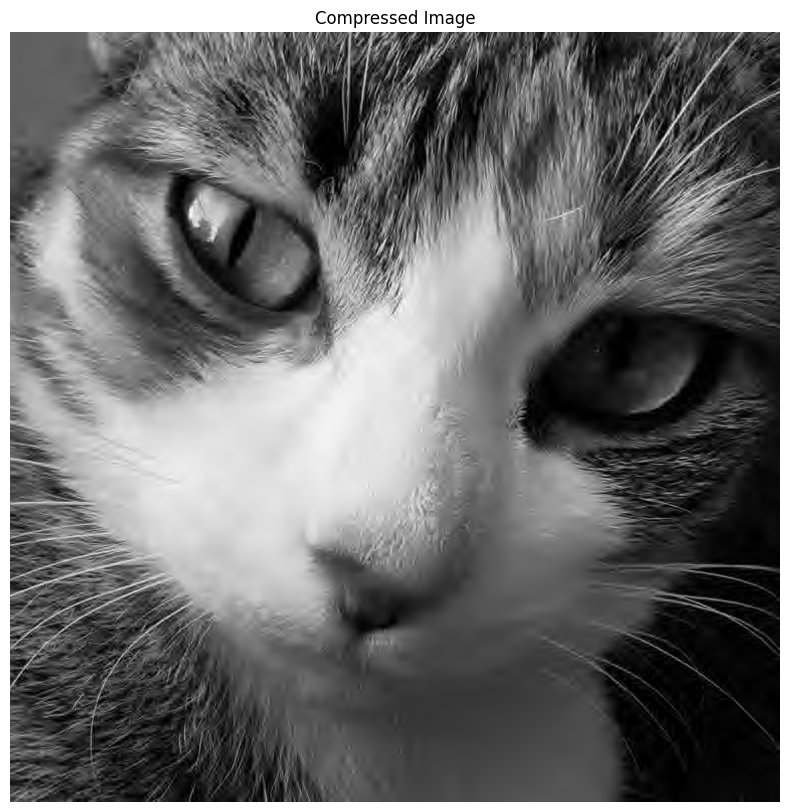

In [50]:
# Your code here
reconstructed = pywt.waverec2(new_coeffs, wavelet="db4")
compressed_image = np.clip(reconstructed, 0, 255)

#plot compressed image
show_image(compressed_image, 'Compressed Image')

What's the compression ratio?

In [51]:
# Your code here
...

# **Putting everything together**

In this exercise we'll analyze the Peak Signal to Noise Ration (PSNR) of the compressed images for different thresholds. For doing so, we'll give you the function to compute the PSNR between the original and compressed image.

In [52]:
def psnr(original_image, compressed_image):
    h,w = original_image.shape
    mse = np.sum(np.abs(original_image-compressed_image)**2)/(h*w)
    return 20* np.log10(255**2/mse)

Now, you have to create a function codec that receives the input image, the wavelet to be used, the number of levels, and the threshold value. This function returns the compressed image and the compression ratio. **Note:** You already did that previously.

In [53]:
def codec(input_image,wavelet='db4',num_levels=6,threshold=100):
  # Your code here
  ...
  return ...

Now, we compare the performance of the 'db4' and the 'bior1.3' wavelets in terms of compression ratio and PSNR for different thresholds.

In [54]:
wavelet_1 = 'db4'
wavelet_2 = 'bior1.3'
thresholds = [5,10,20,40,80,100]
num_levels=6

# Your code here
...

Ellipsis

**QUESTIONS**

1) Which wavelet is better for the Trudy_for_compression.jpeg image and why?

# **Supplementary Exercises**

For the following exercises, you're free to use AI-assisted tools like agents. These exercises are open-ended. You should discuss and analyze your results. In this section, only the results and your discussion will be graded, not the code.

1. Designing and using custom filters with the pyWavelets library
Reference (https://pywavelets.readthedocs.io/en/latest/ref/wavelets.html#wavelet-families)
2. Propose and explore custom wavelets that achieve equivalent or higher compression ratio on the Trudy image explored previously. **P.S** You are free to explore any approach here.

# **Challenge: Wavelet Compression Design**

In this challenge, you will use wavelets to compress an image. The goal is not only to obtain a reconstructed image, but to make design choices and justify them. You may use `pywt` for this part.

---

## Objective

You are given a target compression ratio:

$
\text{compression ratio} \geq 10:1.
$

Your goal is to find a wavelet-based compression strategy that gives the best possible reconstruction quality while satisfying this constraint. You should experiment with:

- the wavelet family,
- the number of decomposition levels,
- the thresholding strategy,
- the threshold value.

---

## Available wavelets

Test at least four different wavelets, for example:

```python
wavelets = ["haar", "db2", "db4", "bior1.3", "bior2.2"]